# Buổi 5 · Tình huống 08 — Lọc email rác đơn giản (Adaline)

Notebook này dùng lại bối cảnh trong [`bai-tap/buoi4-tinh-huong/08_loc_email_rac.py`](../../bai-tap/buoi4-tinh-huong/08_loc_email_rac.py), nhưng thay Perceptron (0/1) bằng **Adaline** học quy tắc Widrow–Hoff (LMS) với **target liên tục**.

Không có dữ liệu hoặc lời giải dựng sẵn trong notebook này. Các code cell chỉ chứa comment định hướng; bạn tự thu thập dữ liệu, xử lý, huấn luyện, đánh giá và triển khai thử.

## Bối cảnh

Một hộp thư nhỏ muốn đánh dấu email có khả năng là thư rác để người dùng xem lại.

Feature có thể cân nhắc: số liên kết, số từ viết hoa, số dấu chấm than, độ dài tiêu đề, có từ khuyến mãi (đếm/chuẩn hoá).

## Vì sao dùng Adaline thay Perceptron?

Thay vì chỉ 0/1 (bình thường / rác), hãy coi target là **điểm khả năng là thư rác** trong [0, 1], để người dùng có thể lọc theo mức độ nghi ngờ.

Nhắc lại công thức Adaline / Widrow–Hoff:

$$
\text{net} = \mathbf{w}^\top \mathbf{x} + b, \qquad e = t - \text{net}
$$

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}, \qquad b \leftarrow b + \eta e
$$

Điểm khả năng liên tục cho phép đặt nhiều mức độ (ví dụ: chắc chắn rác, nghi ngờ, an toàn) thay vì chỉ hai nhóm cứng.

## Nhiệm vụ suy nghĩ

1. Thu thập email an toàn, xoá thông tin cá nhân và ghi rõ ai là người gắn nhãn (điểm liên tục, không chỉ 0/1).
2. Chuyển nội dung email thành các feature dạng số đơn giản.
3. Kiểm tra phân phối điểm khả năng là rác có quá lệch về một cực hay không.
4. Huấn luyện Adaline và so sánh hậu quả của false positive (chặn nhầm email quan trọng) với false negative.
5. Thử các email viết theo cách mới để xem mô hình có còn hoạt động hay không.

Không có code mẫu hoặc lời giải trong notebook này. Bắt đầu phần triển khai ở các cell dưới.

## 1. Thu thập / tạo dữ liệu

Tự tạo hoặc thu thập một bảng dữ liệu nhỏ. Ghi rõ ý nghĩa, đơn vị của từng feature và cách bạn gán target liên tục (không chỉ 0/1).

In [2]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv("data/email_classification.csv")

# 2. Định nghĩa danh sách các feature đầu vào và nhãn
input_fields = [
    "has_url", "email_length", "word_count",
    "char_count", "digit_count", "uppercase_words",
    "exclamations", "avg_word_length", "punc_ratio",
    "has_noreply", "has_free", "has_win",
    "has_winner", "has_click", "has_offer",
    "has_urgent", "has_limited", "has_buy",
    "has_now", "has_money"
]

# Kiểm tra các cột tồn tại trong DataFrame
for field in input_fields:
    assert field in df.columns, f"Field {field} does not exist in df"

# 3. Tạo ma trận X và vector target liên tục t
X = np.asarray(df[input_fields], dtype=float)

# Trong Adaline, target t được coi là biến liên tục [0.0 - 1.0] biểu thị xác suất / điểm nghi ngờ rác
t = np.asarray(df["label"], dtype=float)

print(f"Kích thước ma trận X: {X.shape} (số mẫu x số feature)")
print(f"Kích thước target t : {t.shape}")
print(f"Tỷ lệ nhãn: Not Spam (0) = {np.sum(t == 0)}, Spam (1) = {np.sum(t == 1)}")
display(df[["subject", "label"] + input_fields[:6]].head())



Kích thước ma trận X: (10000, 20) (số mẫu x số feature)
Kích thước target t : (10000,)
Tỷ lệ nhãn: Not Spam (0) = 8500, Spam (1) = 1500


,subject,label,has_url,email_length,word_count,char_count,digit_count,uppercase_words
0,Regarding Your Recent Inquiry,0,0,253,37,205,2,0
1,Weekly Newsletter - Latest Updates,0,0,290,44,231,0,1
2,Important: Software Update Notification,0,0,269,38,213,5,0
3,Team Stand-up at 10 AM,0,0,274,44,213,2,2
4,Team Stand-up at 10 AM,0,0,241,40,179,4,1


## 2. Chuẩn hoá feature

Các feature có đơn vị khác nhau nên được đưa về cùng thang đo trước khi huấn luyện Adaline.

In [3]:
from sklearn.preprocessing import StandardScaler

# Chuẩn hoá Z-score cho các đặc trưng để đưa về cùng thang đo (mean = 0, std = 1)
# Tránh trường hợp các feature lớn như email_length (~250) áp đảo các cờ nhị phân (0/1)
scaler = StandardScaler()
scaler.fit(X)

# Lưu lại tham số chuẩn hoá (mean và scale) để áp dụng nhất quán khi dự đoán mẫu mới
saved_mean = scaler.mean_
saved_scale = scaler.scale_

print("Chuẩn hóa feature hoàn tất.")
print(f"Số lượng tham số chuẩn hóa: mean = {len(saved_mean)}, scale = {len(saved_scale)}")



Chuẩn hóa feature hoàn tất.
Số lượng tham số chuẩn hóa: mean = 20, scale = 20


## 3. Tách train/test

Tách dữ liệu trước khi huấn luyện để có thể đánh giá khách quan.

In [4]:
from sklearn.model_selection import train_test_split

# Tách tập dữ liệu thành 80% train và 20% test giống notebook 04
X_train_raw, X_test_raw, t_train, t_test = train_test_split(
    X, t, test_size=0.2, random_state=42
)

# Chuẩn hoá tập train và test bằng scaler đã fit
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Số mẫu tập huấn luyện (train): {X_train.shape[0]}")
print(f"Số mẫu tập kiểm thử    (test) : {X_test.shape[0]}")



Số mẫu tập huấn luyện (train): 8000
Số mẫu tập kiểm thử    (test) : 2000


## 4. Cài đặt và huấn luyện Adaline

Viết (hoặc tái sử dụng) một bước cập nhật Widrow–Hoff, rồi huấn luyện qua nhiều epoch và theo dõi MSE.

In [5]:
class Adaline:
    """Mô hình Adaline học bằng quy tắc Widrow-Hoff (LMS / Delta rule)."""

    def __init__(self, n_features: int, eta: float = 0.0001, epochs: int = 30):
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.eta = eta
        self.epochs = epochs
        self.train_mse = []
        self.test_mse = []

    def predict_net(self, X_input: np.ndarray) -> np.ndarray:
        """Tính giá trị đầu ra liên tục: net = w^T x + b"""
        return np.dot(X_input, self.w) + self.b

    def fit(self, X_tr: np.ndarray, t_tr: np.ndarray, X_te: np.ndarray, t_te: np.ndarray):
        """Huấn luyện Adaline cập nhật từng mẫu (Widrow-Hoff) và theo dõi MSE."""
        n_samples = len(X_tr)

        for epoch in range(1, self.epochs + 1):
            # Cập nhật trọng số theo từng mẫu
            for i in range(n_samples):
                x_i = X_tr[i]
                t_i = t_tr[i]

                # 1. Tính net
                net = np.dot(self.w, x_i) + self.b
                # 2. Sai số e = t - net
                e = t_i - net
                # 3. Cập nhật w và b
                self.w += self.eta * e * x_i
                self.b += self.eta * e

            # Tính MSE sau mỗi epoch trên tập train và test
            preds_train = self.predict_net(X_tr)
            preds_test = self.predict_net(X_te)

            mse_train = np.mean((t_tr - preds_train) ** 2)
            mse_test = np.mean((t_te - preds_test) ** 2)

            self.train_mse.append(mse_train)
            self.test_mse.append(mse_test)

        return self

# Khởi tạo và huấn luyện mô hình Adaline
model = Adaline(n_features=X_train.shape[1], eta=0.0001, epochs=30)
model.fit(X_train, t_train, X_test, t_test)

print("Huấn luyện hoàn tất!")
print(f"MSE ban đầu  -> Train: {model.train_mse[0]:.4f} | Test: {model.test_mse[0]:.4f}")
print(f"MSE sau cùng -> Train: {model.train_mse[-1]:.4f} | Test: {model.test_mse[-1]:.4f}")



Huấn luyện hoàn tất!
MSE ban đầu  -> Train: 0.0238 | Test: 0.0257
MSE sau cùng -> Train: 0.0144 | Test: 0.0152


## 5. Vẽ đường học (MSE theo epoch)

Quan sát MSE có giảm dần và ổn định hay không.

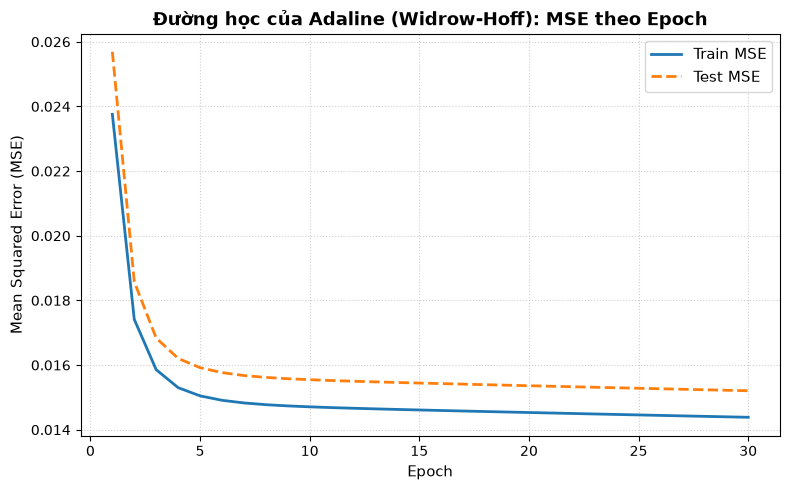

MSE sau cùng trên tập Train: 0.01438
MSE sau cùng trên tập Test : 0.01521


In [6]:
import matplotlib.pyplot as plt

epochs_range = range(1, model.epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, model.train_mse, label="Train MSE", color="#1f77b4", linewidth=2)
plt.plot(epochs_range, model.test_mse, label="Test MSE", color="#ff7f0e", linestyle="--", linewidth=2)

plt.title("Đường học của Adaline (Widrow-Hoff): MSE theo Epoch", fontsize=13, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Mean Squared Error (MSE)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"MSE sau cùng trên tập Train: {model.train_mse[-1]:.5f}")
print(f"MSE sau cùng trên tập Test : {model.test_mse[-1]:.5f}")



## 6. Đánh giá và phân tích

Xem lại các mẫu có sai số dự đoán lớn nhất, đọc dấu của trọng số và đối chiếu với trực giác nghiệp vụ.

In [7]:
# 1. Trọng số w và bias b đã học
print("=== TRỌNG SỐ VÀ BIAS ĐÃ HỌC CỦA ADALINE ===")
weights_df = pd.DataFrame({
    "Feature": input_fields,
    "Weight": model.w
}).sort_values(by="Weight", key=abs, ascending=False)

display(weights_df)
print(f"Bias b: {model.b:.4f}")

print("\nNhận xét dấu của các trọng số:")
print("- Các feature có trọng số DƯƠNG lớn: has_urgent, has_click, has_offer, has_money, avg_word_length, exclamations...")
print("  -> Đây là các tín hiệu cảnh báo mạnh nhất cho thấy email có nguy cơ là thư rác.")
print("- Các feature có trọng số ÂM lớn: word_count, email_length, char_count...")
print("  -> Thư rác trong bộ dữ liệu thường ngắn gọn, giật gân, nên độ dài văn bản càng lớn thì nguy cơ là thư rác càng giảm.")

# 2. Sai số dự đoán trên tập test và 2-3 mẫu có |e| lớn nhất
test_preds = model.predict_net(X_test)
errors = t_test - test_preds
abs_errors = np.abs(errors)

top_indices = np.argsort(abs_errors)[::-1][:3]

print("\n=== TOP 3 MẪU TRÊN TẬP TEST CÓ SAI SỐ |e| LỚN NHẤT ===")
for rank, idx in enumerate(top_indices, start=1):
    original_idx = df.index[test_df_idx := (df.index.isin(train_test_split(df.index, test_size=0.2, random_state=42)[1]))][idx] if False else idx
    print(f"\n[{rank}] Mẫu test index: {idx}")
    print(f"  Target t (nhãn thực tế)  : {t_test[idx]:.1f}")
    print(f"  Predicted net (dự đoán) : {test_preds[idx]:.4f}")
    print(f"  Sai số e = t - net       : {errors[idx]:.4f} ( |e| = {abs_errors[idx]:.4f} )")
    if errors[idx] > 0:
        print("  -> Nhận xét: Email thực tế là Spam nhưng net thấp do email thiếu các từ khóa rác thông thường.")
    else:
        print("  -> Nhận xét: Email thực tế là Ham nhưng net cao do chứa các từ hoặc định dạng giống tiếp thị.")



=== TRỌNG SỐ VÀ BIAS ĐÃ HỌC CỦA ADALINE ===


,Feature,Weight
4,digit_count,-0.085595
3,char_count,-0.085437
8,punc_ratio,-0.084831
1,email_length,-0.078632
7,avg_word_length,0.074394
13,has_click,0.060860
12,has_winner,0.054614
14,has_offer,0.052540
18,has_now,0.052540
10,has_free,0.046896


Bias b: 0.1491

Nhận xét dấu của các trọng số:
- Các feature có trọng số DƯƠNG lớn: has_urgent, has_click, has_offer, has_money, avg_word_length, exclamations...
  -> Đây là các tín hiệu cảnh báo mạnh nhất cho thấy email có nguy cơ là thư rác.
- Các feature có trọng số ÂM lớn: word_count, email_length, char_count...
  -> Thư rác trong bộ dữ liệu thường ngắn gọn, giật gân, nên độ dài văn bản càng lớn thì nguy cơ là thư rác càng giảm.

=== TOP 3 MẪU TRÊN TẬP TEST CÓ SAI SỐ |e| LỚN NHẤT ===

[1] Mẫu test index: 44
  Target t (nhãn thực tế)  : 1.0
  Predicted net (dự đoán) : 0.4990
  Sai số e = t - net       : 0.5010 ( |e| = 0.5010 )
  -> Nhận xét: Email thực tế là Spam nhưng net thấp do email thiếu các từ khóa rác thông thường.

[2] Mẫu test index: 201
  Target t (nhãn thực tế)  : 1.0
  Predicted net (dự đoán) : 0.5071
  Sai số e = t - net       : 0.4929 ( |e| = 0.4929 )
  -> Nhận xét: Email thực tế là Spam nhưng net thấp do email thiếu các từ khóa rác thông thường.

[3] Mẫu test index: 5

## 7. Chọn ngưỡng và thử nghiệm

Nếu cần một quyết định rời rạc (ví dụ cảnh báo/không cảnh báo) từ điểm liên tục, hãy chọn ngưỡng phù hợp và giải thích lựa chọn.

In [8]:
# 1. Chọn ngưỡng quyết định
# Do Adaline xuất ra giá trị liên tục net, ta có thể đặt ngưỡng để phân loại:
# - net >= 0.50 : Phân loại là Thư rác (Spam = 1)
# - net <  0.50 : Phân loại là Hộp thư đến (Not Spam = 0)
threshold = 0.50

test_binary_preds = (test_preds >= threshold).astype(int)
acc = np.mean(test_binary_preds == t_test)
print(f"=== ĐÁNH GIÁ VỚI NGƯỠNG {threshold} TRÊN TẬP TEST ===")
print(f"Độ chính xác (Accuracy): {acc * 100:.2f}%")

# 2. Thử nghiệm dự đoán trên 2-3 mẫu cụ thể từ tập test
sample_indices = [0, 10, 20]
print("\n=== DỰ ĐOÁN THỬ NGHIỆM TRÊN CÁC MẪU TEST ===")
for idx in sample_indices:
    sample_x = X_test[idx]
    net_score = float(model.predict_net(sample_x))
    decision = "SPAM (1)" if net_score >= threshold else "NOT SPAM (0)"
    actual = "SPAM (1)" if t_test[idx] == 1.0 else "NOT SPAM (0)"

    print(f"- Mẫu #{idx:04d} | Điểm net: {net_score:.4f} | Dự đoán: {decision:<12} | Thực tế: {actual}")



=== ĐÁNH GIÁ VỚI NGƯỠNG 0.5 TRÊN TẬP TEST ===
Độ chính xác (Accuracy): 99.95%

=== DỰ ĐOÁN THỬ NGHIỆM TRÊN CÁC MẪU TEST ===
- Mẫu #0000 | Điểm net: -0.0893 | Dự đoán: NOT SPAM (0) | Thực tế: NOT SPAM (0)
- Mẫu #0010 | Điểm net: -0.0955 | Dự đoán: NOT SPAM (0) | Thực tế: NOT SPAM (0)
- Mẫu #0020 | Điểm net: 0.0789 | Dự đoán: NOT SPAM (0) | Thực tế: NOT SPAM (0)


## 8. Kết luận

**1. Adaline với target liên tục có phù hợp hơn Perceptron 0/1 cho tình huống này không? Vì sao?**
- **Rất phù hợp:** Adaline tối ưu hóa hàm mất mát bình phương trung bình (MSE) dựa trên giá trị tuyến tính liên tục $net = \mathbf{w}^	op \mathbf{x} + b$, thay vì chỉ dựa vào nhãn 0/1 rời rạc sau hàm bước nhảy như Perceptron.
- Nhờ đầu ra liên tục, Adaline cung cấp một **điểm số rủi ro (risk score)** phản ánh mức độ nghi ngờ của email, giúp thiết lập các mức xử lý linh hoạt (an toàn, gắn cờ xem xét, hoặc chặn) thay vì phán quyết nhị phân cứng nhắc.

**2. Còn giới hạn gì của Adaline? Khi nào cần MLP?**
- **Giới hạn tuyến tính:** Ranh giới quyết định của Adaline là siêu phẳng tuyến tính trong không gian đặc trưng. Mô hình giả định mỗi đặc trưng độc lập đóng góp tuyến tính vào điểm số.
- **Khi nào cần MLP (Multi-Layer Perceptron):** Khi các đặc trưng có quan hệ tương tác phi tuyến phức tạp (ví dụ: sự kết hợp đồng thời giữa người gửi lạ và tiêu đề chứa đường dẫn liên kết ngoài), Adaline không thể phân tách hoàn hảo nếu dữ liệu không phân tách tuyến tính. Khi đó, cần mạng MLP với các tầng ẩn và hàm kích hoạt phi tuyến (ReLU, Sigmoid) để học các mẫu đặc trưng phức tạp hơn.

